<html> <h1 style="font-style:italic; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-7 </h1> </html>


<html> <h2 style="font-style:italic; color:blue;"> Transfer Learning </h2> </html>



<html> <h3 style="font-style:italic; color:blue;"> CIFAR10 Transfer Learning based Classifier </h3> </html>


<html> <h3 style="font-style:italic; color:blue;"> VGG16 and VGG19</h3> </html>


##### This notebook outlines the steps to build a classifier to leverage concepts of Transfer Learning by utilising a pretrained Deep-CNNs.


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [ ]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

cat: '/proc/driver/nvidia/gpus/0000:00:04.0/information': No such file or directory



### Restart the Kernel

_________________________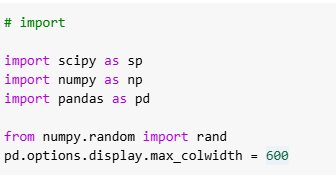

In [ ]:
import scipy as sp

import numpy as np

import pandas as pd
# import
from numpy.random import rand
pd.options.display.max_colwidth = 600

In [ ]:
#

___________________________________________________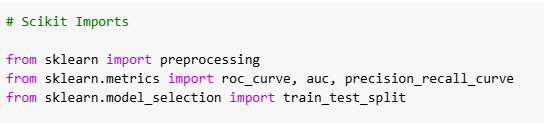

In [ ]:
# Scikit Imports
from sklearn import preprocessing
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split


In [ ]:
#

__________________________________________________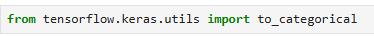

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
#

___________________________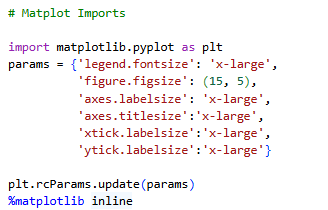

In [ ]:
# Matplot Imports
import matplotlib.pyplot as plt
params = {
    'legend.fontsize': 'x-large',
    'figure.figsize': (15, 5),
    'axes.labelsize': 'x-large',
    'axes.titlesize': 'x-large',
    'xtick.labelsize': 'x-large',
    'ytick.labelsize': 'x-large'
}
plt.rcParams.update(params)
%matplotlib inline

In [ ]:
#

______________________________________________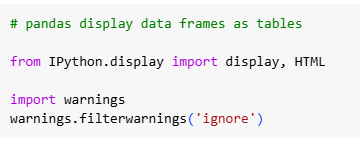

In [ ]:
from IPython.core.display import display,HTML
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#

_________________________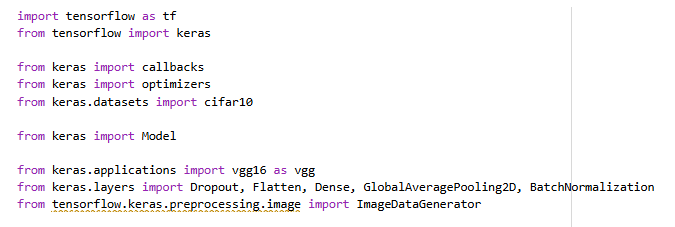

In [ ]:
import tensorflow as tf
from tensorflow import keras

from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10
from keras import Model

from keras.applications import vgg16 as vgg
from keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D, BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#

### Load and manipulate the DataSet

____________________________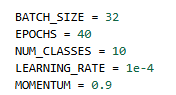

In [ ]:
BATCH_SIZE = 32
EPOCHS = 40
NUM_CLASSES = 10
LEARNING_RATE = 1e-4
MOMENTUM = 0.9

In [ ]:
#

__________________________________________________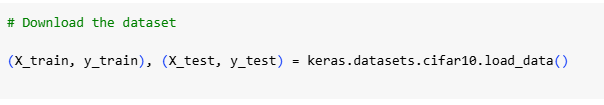

In [ ]:
(X_train, y_train), (X_test, Y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
#

__________________________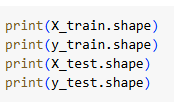

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [ ]:
#

______________________________________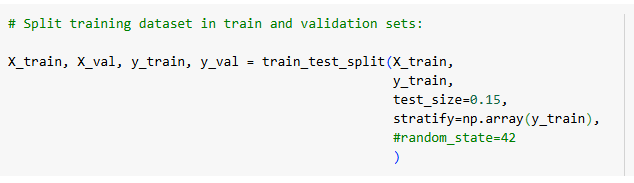

In [ ]:


# Split training dataset into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    stratify=np.array(y_train),
    random_state=42
)

In [ ]:
#

______________________________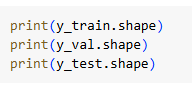

In [ ]:
print(y_train.shape)
print(y_val.shape)
print(Y_test.shape)

(42500, 1)
(7500, 1)
(10000, 1)


In [ ]:
#

Checks for free memory:

_____________________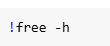

In [ ]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           230Gi       2.0Gi       223Gi       3.0Mi       4.1Gi       226Gi
Swap:             0B          0B          0B


In [ ]:
#

______________________________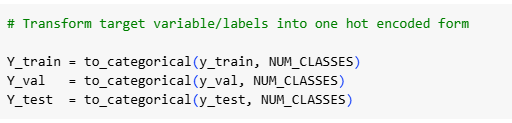

In [ ]:
from tensorflow.keras.utils import to_categorical

# Transform target labels into one-hot encoded format
Y_train = to_categorical(y_train, NUM_CLASSES)
Y_val   = to_categorical(y_val, NUM_CLASSES)
Y_test  = to_categorical(Y_test, NUM_CLASSES)

In [ ]:
#

____________________________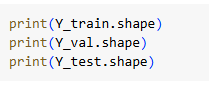

In [ ]:
print(Y_train.shape)
print(Y_val.shape)
print(Y_test.shape)

(42500, 10)
(7500, 10)
(10000, 10)


In [ ]:
#

### Preprocessing

In [ ]:
# Since we are about to use VGG16 and VGG19as a feature extractor, the minimum size of an image its take is 48x48.
# We utilize ```scipy`` to resize images to required dimensions


_______________________________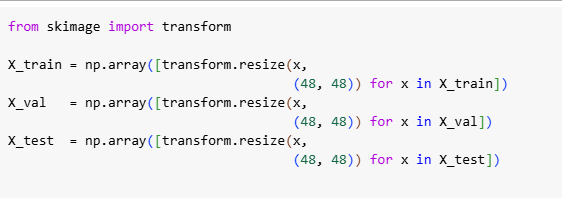

In [ ]:
import numpy as np
from skimage import transform

X_train = np.array([transform.resize(x, (48, 48)) for x in X_train])
X_val   = np.array([transform.resize(x, (48, 48)) for x in X_val])
X_test  = np.array([transform.resize(x, (48, 48)) for x in X_test])

In [ ]:
#

_____________________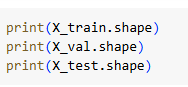

In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(42500, 48, 48, 3)
(7500, 48, 48, 3)
(10000, 48, 48, 3)


In [ ]:
#

____________________________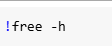

In [ ]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           230Gi       5.4Gi       220Gi       3.0Mi       4.2Gi       222Gi
Swap:             0B          0B          0B


In [ ]:
#

# Create VGG19 Model

- Load VGG16 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


_______________________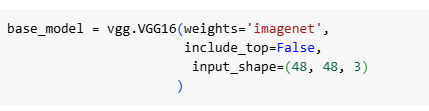

In [ ]:
base_model = vgg.VGG16(weights = 'imagenet', include_top = False, input_shape=(48, 48, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#

____________________________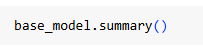

In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#

________________________________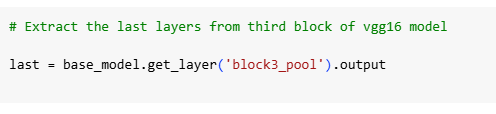

In [ ]:
last = base_model.get_layer('block3_pool').output

In [ ]:
#

______________________________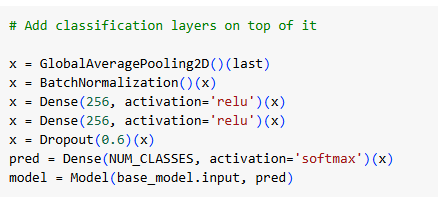

In [ ]:
from ast import Num
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation= 'relu')(x)
x = Dense(256, activation = 'relu')(x)
x = Dropout(0.6)(x)
pred = Dense(NUM_CLASSES, activation= 'softmax')(x)
model = Model(base_model.input, pred)

In [ ]:
#

____________________________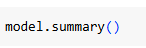

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,870,666 (7.14 MB)

 Trainable params: 1,870,154 (7.13 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
#

_____________________________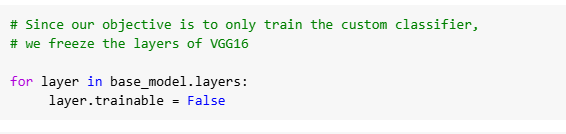

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
#

_________________________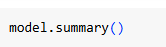

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,870,666 (7.14 MB)

 Trainable params: 134,666 (526.04 KB)

 Non-trainable params: 1,736,000 (6.62 MB)

In [ ]:
#

_______________________________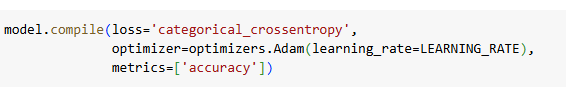

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer = optimizers.Adam(learning_rate = LEARNING_RATE), metrics = ['accuracy'])

In [ ]:
#

### EarlyStopping

___________________________image.png

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#

In [ ]:
LAST_DIGIT_IN_YOUR_SID = 9

early_stop = EarlyStopping(monitor='val_loss', patience=LAST_DIGIT_IN_YOUR_SID)

### Data Augmentation


To help model generalize and overcome the limitations of a small dataset, we prepare augmented datasets using keras  utilities


___________________________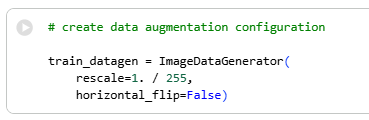

In [ ]:
# create data augmentation configuration
train_datagen = ImageDataGenerator(
rescale=1. / 255, horizontal_flip=False)

In [ ]:
#

_________________________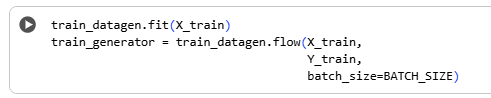

In [ ]:
train_datagen.fit(X_train)
train_generator = train_datagen. flow(X_train,
Y_train, batch_size=BATCH_SIZE)

In [ ]:
#

__________________________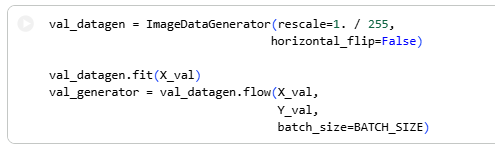

In [ ]:


val_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=False
)

val_datagen.fit(X_val)

val_generator = val_datagen.flow(
    X_val,
    Y_val,
    batch_size=BATCH_SIZE
)

In [ ]:
#

### Train the Model

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell
</h4> </html>

In [ ]:
train_steps_per_epoch = X_train.shape[0] // BATCH_SIZE
val_steps_per_epoch = X_val.shape[0] // BATCH_SIZE

___________________________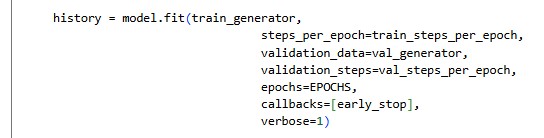

In [ ]:
history = model.fit(train_generator,

steps_per_epoch=train_steps_per_epoch,

validation_data=val_generator,

validation_steps=val_steps_per_epoch,

epochs=EPOCHS,

callbacks=[early_stop],

verbose=1)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.2662 - loss: 2.0361 - val_accuracy: 0.4810 - val_loss: 1.5028
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step - accuracy: 0.2812 - loss: 1.8488 - val_accuracy: 0.4810 - val_loss: 1.5025
Epoch 3/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4456 - loss: 1.5610 - val_accuracy: 0.5296 - val_loss: 1.3353
Epoch 4/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 0s 309us/step - accuracy: 0.3438 - loss: 1.6092 - val_accuracy: 0.5303 - val_loss: 1.3344
Epoch 5/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4916 - loss: 1.4170 - val_accuracy: 0.5556 - val_loss: 1.2563
Epoch 6/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 0s 307us/step - accuracy: 0.4688 - loss: 1.1893 - val_accuracy: 0.5564 - val_loss: 1.2561
Epoch 7/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5291 - loss: 1.3319 - val_accuracy: 0.5726 - val_loss: 1.2038
Epoch 8/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 0s 312us/step - accuracy: 0.6250 - loss: 

In [ ]:
#

### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using </h4> </html>

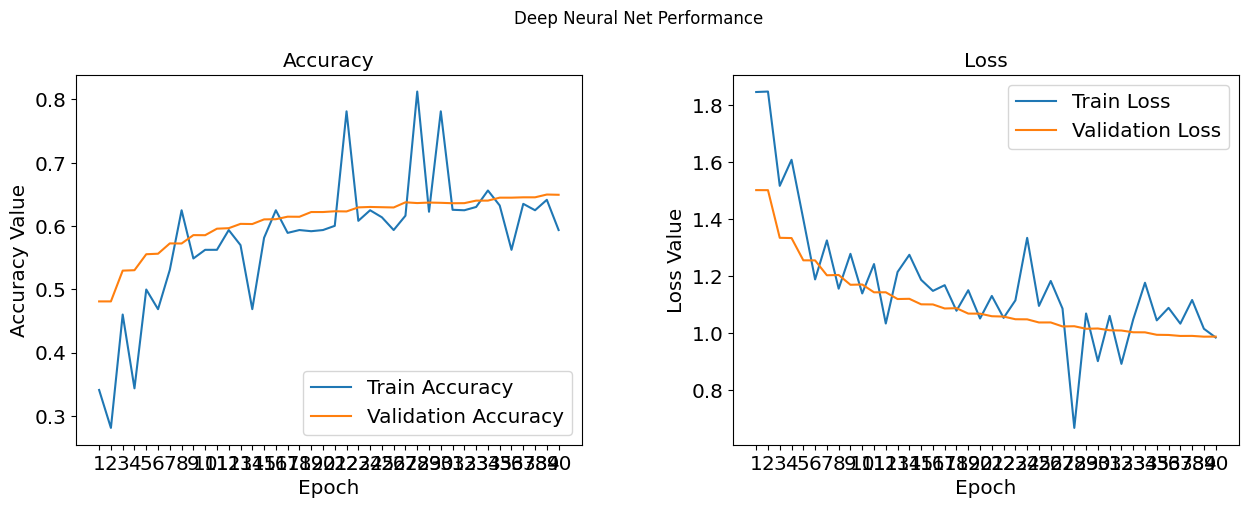

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epochs = list(range(1,EPOCHS+1))
ax1.plot(epochs, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(epochs)
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epochs, history.history['loss'], label='Train Loss')
ax2.plot(epochs, history.history['val_loss'], label='Validation Loss')
ax2.set_xticks(epochs)
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")


___________________________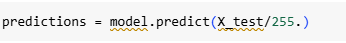

In [ ]:
predictions = model.predict(X_test/255.)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [ ]:
#

_________________________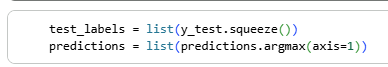

In [ ]:
test_labels = list(Y_test.squeeze())
predictions = list(predictions.argmax(axis = 1))

In [ ]:
#

___________________________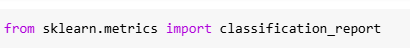

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
#

___________________________________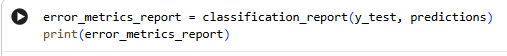

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions from the model
predictions = model.predict(X_test)

# Convert one-hot encoded labels to class labels
y_true = np.argmax(Y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)

# Print classification report
error_metrics_report = classification_report(y_true, y_pred)
print(error_metrics_report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.65      0.05      0.09      1000
           1       0.03      0.00      0.01      1000
           2       0.00      0.00      0.00      1000
           3       0.09      0.42      0.14      1000
           4       0.12      0.00      0.00      1000
           5       0.06      0.00      0.00      1000
           6       0.00      0.00      0.00      1000
           7       0.04      0.01      0.01      1000
           8       0.14      0.56      0.23      1000
           9       0.06      0.05      0.05      1000

    accuracy                           0.11     10000
   macro avg       0.12      0.11      0.05     10000
weighted avg       0.12      0.11      0.05     10000



In [ ]:
#

_________________________________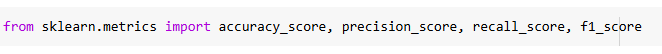

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
#

________________________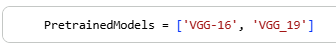

In [ ]:
PretrainedModels = ['VGG-16', 'VGG_19']

In [ ]:
#

___________________________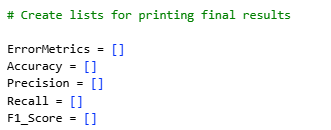

In [ ]:
# Create lists for printing final results
ErrorMetrics = []
Accuracy = []
Precision = []
Recall = []
F1_Score = []

In [ ]:
#

____________________________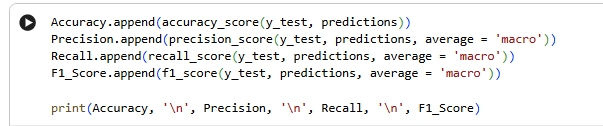

In [ ]:


Accuracy.append(accuracy_score(y_true, y_pred))
Precision.append(precision_score(y_true, y_pred, average='macro'))
Recall.append(recall_score(y_true, y_pred, average='macro'))
F1_Score.append(f1_score(y_true, y_pred, average='macro'))



In [ ]:
#

### Visualise Predictions

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4> </html>

In [ ]:
#label_dict = {0:'airplane',
#             1:'automobile',
#             2:'bird',
#             3:'cat',
#             4:'deer',
#             5:'dog',
#             6:'frog',
#             7:'horse',
#             8:'ship',
#             9:'truck'}

classes=['airplane', 'automobile', 'bird', 'cat', 'deer',
 'dog', 'frog', 'houre', 'ship', 'truck']

In [ ]:
# Graph this to look at the full set of 10 class predictions.


def plot_image(i,predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(label_dict[predicted_label],
                                    100 * np.max(predictions_array),
                                    label_dict[true_label]),
                                    color=color)

___________________________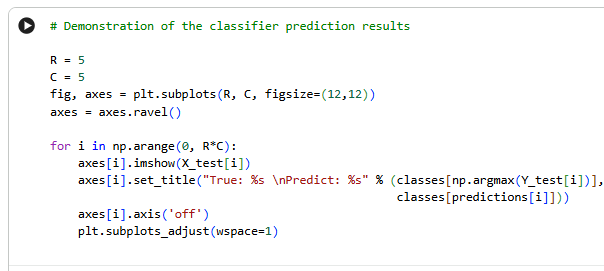

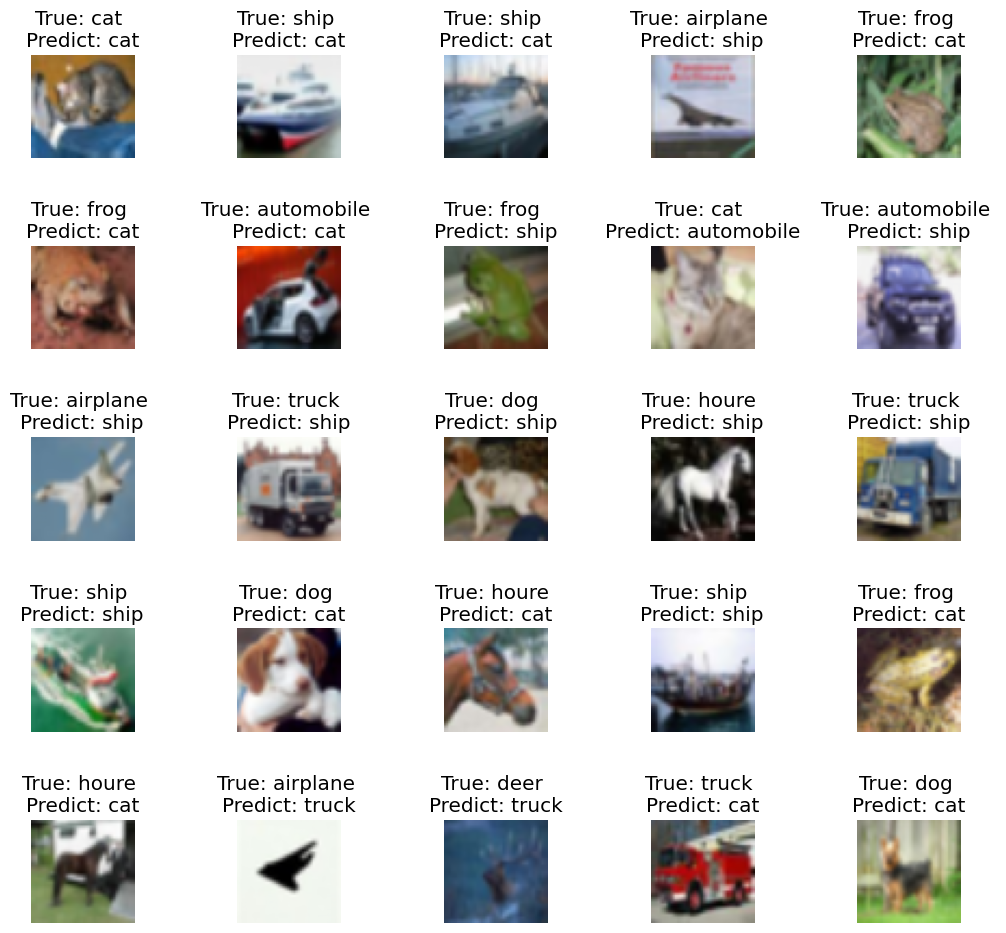

In [85]:
R = 5
C = 5

fig, axes = plt.subplots(R, C, figsize=(12, 12))
axes = axes.ravel()

for i in np.arange(0, R*C):
    axes[i].imshow(X_test[i])
    axes[i].set_title(
        "True: %s \nPredict: %s" % (
            classes[np.argmax(Y_test[i])],
            classes[np.argmax(predictions[i])]
        )
    )
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)
plt.show()

# Create VGG19 Model

- Load VGG19 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


_________________________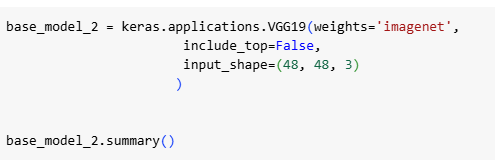

In [86]:
base_model_2 = keras. applications. VGG19(weights= 'imagenet' ,
include_top=False, input_shape= (48, 48, 3)
)
base_model_2.summary ()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#

___________________________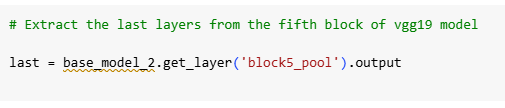

In [87]:
# Extract the last layers from the fifth block of vgg19 model
last = base_model_2.get_layer ('block5_pool').output

In [ ]:
#

_______________________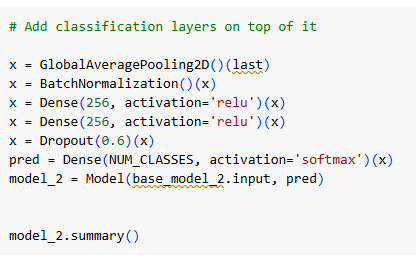

In [88]:
# Add classification layers on top of it
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.6)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)

model_2 = Model(base_model_2.input, pred)

model_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,226,122 (77.16 MB)

 Trainable params: 20,225,098 (77.15 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
#

_________________________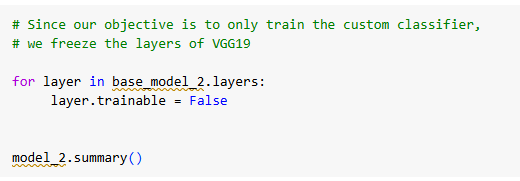

In [89]:
# Since our objective is to only train the custom classifier,
# we freeze the layers of VGG19
for layer in base_model_2.layers:
  layer.trainable = False
model_2. summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,226,122 (77.16 MB)

 Trainable params: 200,714 (784.04 KB)

 Non-trainable params: 20,025,408 (76.39 MB)

In [ ]:
#

_______________________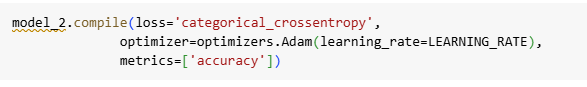

In [95]:
model_2.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

In [91]:
import numpy as np
from skimage import transform

X_train = np.array([transform.resize(x, (75, 75)) for x in X_train])
X_val   = np.array([transform.resize(x, (75, 75)) for x in X_val])
X_test  = np.array([transform.resize(x, (75, 75)) for x in X_test])

### Train the Model_2

____________________________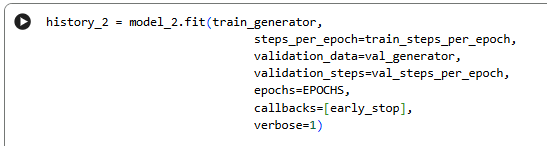

In [96]:
history_2 = model_2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2115 - loss: 2.1771 - val_accuracy: 0.3341 - val_loss: 1.8533
Epoch 2/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3132 - loss: 1.8696 - val_accuracy: 0.3680 - val_loss: 1.7500
Epoch 3/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3435 - loss: 1.7942 - val_accuracy: 0.3884 - val_loss: 1.6989
Epoch 4/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3665 - loss: 1.7429 - val_accuracy: 0.4035 - val_loss: 1.6616
Epoch 5/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3768 - loss: 1.7126 - val_accuracy: 0.4161 - val_loss: 1.6314
Epoch 6/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3894 - loss: 1.6821 - val_accuracy: 0.4253 - val_loss: 1.6037
Epoch 7/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3936 - loss: 1.6600 - val_accuracy: 0.4299 - val_loss: 1.5826
Epoch 8/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4039 - loss: 1.6448 -

In [ ]:
#

### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

Find 4 differences in the code with the similar code for VGG16

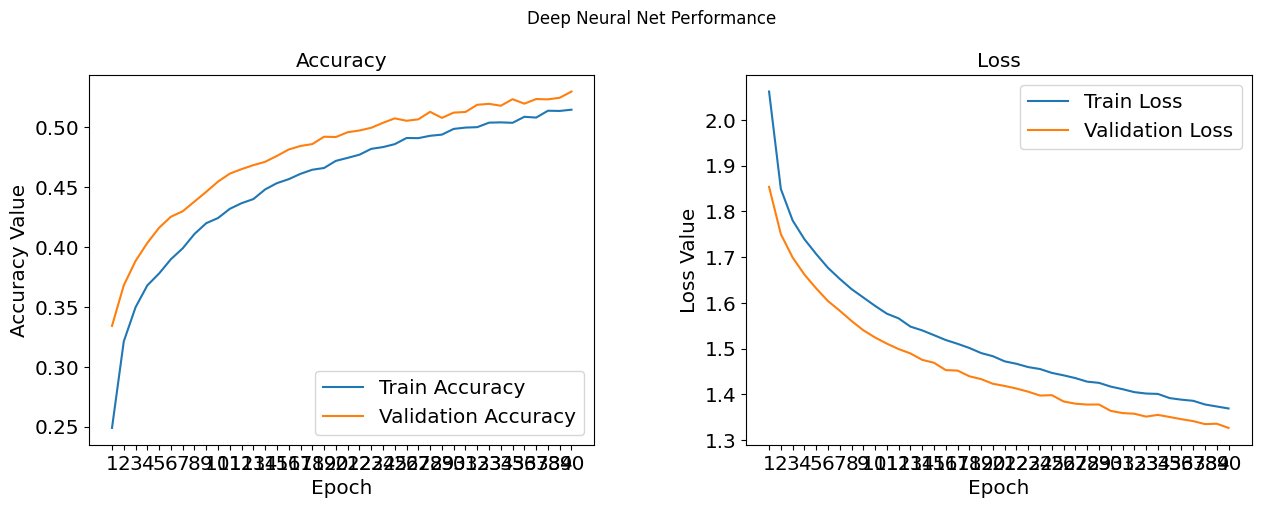

In [97]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epochs = list(range(1,EPOCHS+1))
ax1.plot(epochs, history_2.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history_2.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(epochs)
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epochs, history_2.history['loss'], label='Train Loss')
ax2.plot(epochs, history_2.history['val_loss'], label='Validation Loss')
ax2.set_xticks(epochs)
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")


_______________________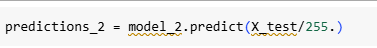

In [100]:
import tensorflow as tf

X_test_resized = tf.image.resize(X_test, (48, 48))
X_test_resized = X_test_resized / 255.0

In [101]:
predictions_2 = model_2.predict(X_test_resized)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


__________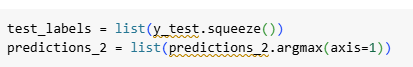

In [103]:
test_labels = list(Y_test.squeeze())
predictions_2 = list(predictions_2.argmax(axis=1))

In [ ]:
#

_____________________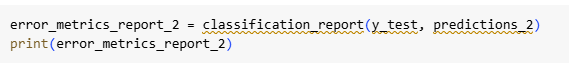

In [106]:
error_metrics_report_2 = classification_report(y_true, y_pred)
print(error_metrics_report_2)

              precision    recall  f1-score   support

           0       0.65      0.05      0.09      1000
           1       0.03      0.00      0.01      1000
           2       0.00      0.00      0.00      1000
           3       0.09      0.42      0.14      1000
           4       0.12      0.00      0.00      1000
           5       0.06      0.00      0.00      1000
           6       0.00      0.00      0.00      1000
           7       0.04      0.01      0.01      1000
           8       0.14      0.56      0.23      1000
           9       0.06      0.05      0.05      1000

    accuracy                           0.11     10000
   macro avg       0.12      0.11      0.05     10000
weighted avg       0.12      0.11      0.05     10000



In [ ]:
#

________________________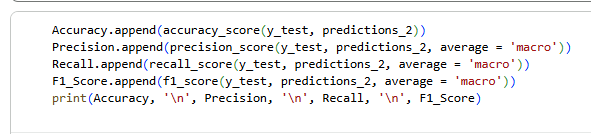

In [108]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = np.argmax(Y_test, axis=1)
y_pred = predictions_2

Accuracy.append(accuracy_score(y_true, y_pred))
Precision.append(precision_score(y_true, y_pred, average='macro'))
Recall.append(recall_score(y_true, y_pred, average='macro'))
F1_Score.append(f1_score(y_true, y_pred, average='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_Score)

[0.109, 0.512] 
 [0.11886204940138492, 0.516253695530185] 
 [0.10900000000000001, 0.512] 
 [0.05442436380103155, 0.5122623453829169]


In [ ]:
#

_______________________________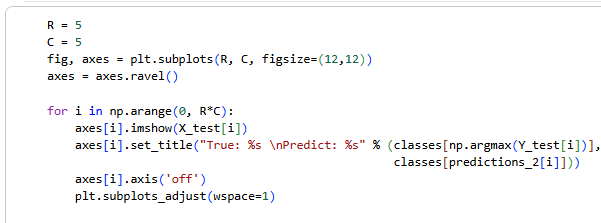

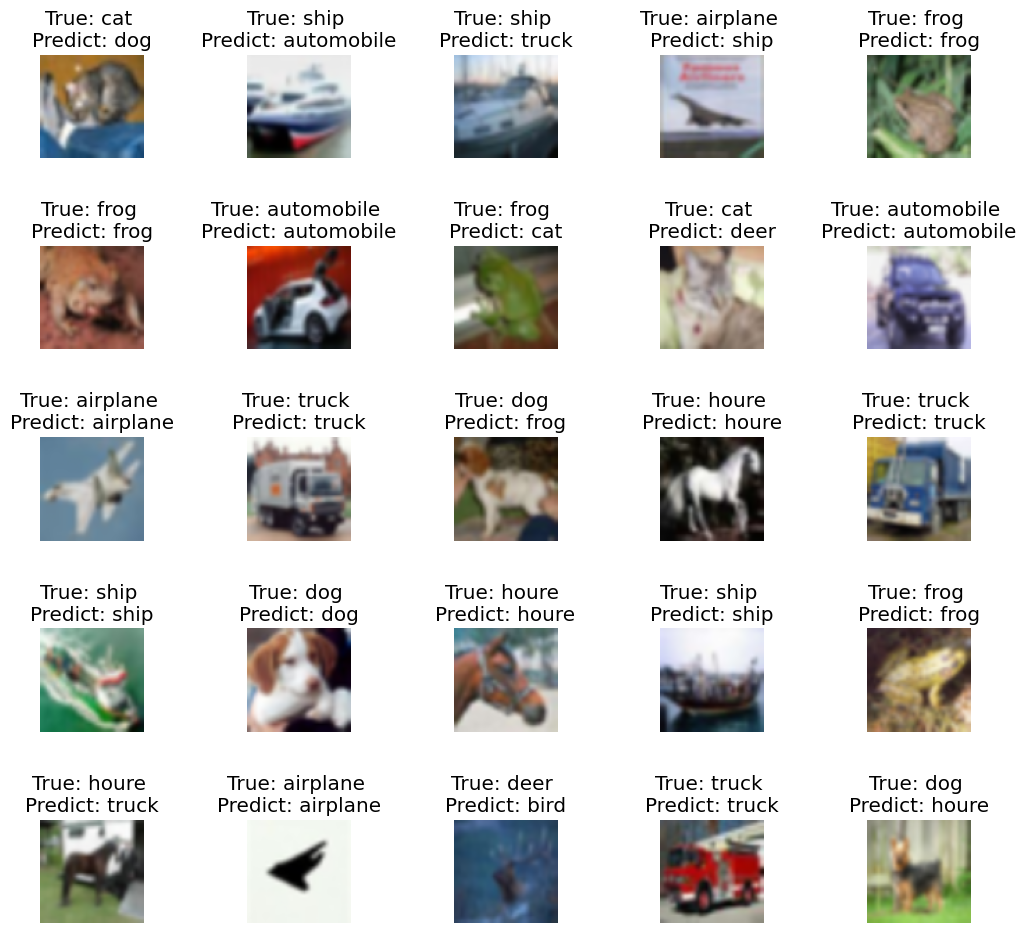

In [109]:
R = 5
C = 5

fig, axes = plt.subplots(R, C, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, R*C):
    axes[i].imshow(X_test[i])
    axes[i].set_title(
        "True: %s \nPredict: %s" % (
            classes[np.argmax(Y_test[i])],
            classes[predictions_2[i]]
        )
    )
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)
plt.show()

In [ ]:
#

_______________________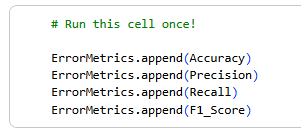

In [111]:
# Run this cell once!
ErrorMetrics.append (Accuracy)
ErrorMetrics.append(Precision)
ErrorMetrics.append(Recall)
ErrorMetrics.append (F1_Score)

________________________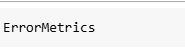

In [112]:
ErrorMetrics

[[0.109, 0.512],
 [0.11886204940138492, 0.516253695530185],
 [0.10900000000000001, 0.512],
 [0.05442436380103155, 0.5122623453829169],
 [0.109, 0.512],
 [0.11886204940138492, 0.516253695530185],
 [0.10900000000000001, 0.512],
 [0.05442436380103155, 0.5122623453829169]]

In [ ]:
#

_________________________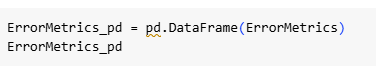

In [113]:
ErrorMetrics_pd = pd.DataFrame (ErrorMetrics)
ErrorMetrics_pd

,0,1
0,0.109000,0.512000
1,0.118862,0.516254
2,0.109000,0.512000
3,0.054424,0.512262
4,0.109000,0.512000
5,0.118862,0.516254
6,0.109000,0.512000
7,0.054424,0.512262


In [ ]:
#

_____________________________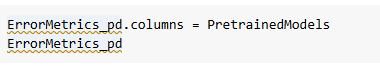

In [116]:
ErrorMetrics_pd.columns = PretrainedModels
ErrorMetrics_pd

,VGG-16,VGG_19
0,0.109000,0.512000
1,0.118862,0.516254
2,0.109000,0.512000
3,0.054424,0.512262
4,0.109000,0.512000
5,0.118862,0.516254
6,0.109000,0.512000
7,0.054424,0.512262


In [ ]:
#

___________________________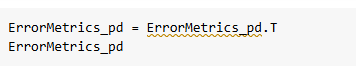

In [117]:
ErrorMetrics_pd = ErrorMetrics_pd.T
ErrorMetrics_pd

,0,1,2,3,4,5,6,7
VGG-16,0.109,0.118862,0.109,0.054424,0.109,0.118862,0.109,0.054424
VGG_19,0.512,0.516254,0.512,0.512262,0.512,0.516254,0.512,0.512262


In [ ]:
#

__________________________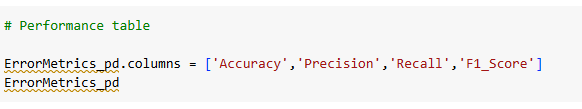

In [132]:
Accuracy = [0.109, 0.512]
Precision = [0.118862, 0.516254]
Recall = [0.109, 0.512]
F1_Score = [0.054424, 0.512262]
import pandas as pd

ErrorMetrics_pd = pd.DataFrame({
    'Accuracy': Accuracy,
    'Precision': Precision,
    'Recall': Recall,
    'F1_Score': F1_Score
}, index=['VGG16', 'VGG19'])

ErrorMetrics_pd

,Accuracy,Precision,Recall,F1_Score
VGG16,0.109,0.118862,0.109,0.054424
VGG19,0.512,0.516254,0.512,0.512262


_________________________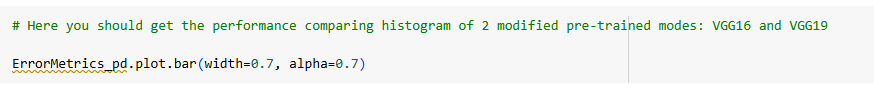

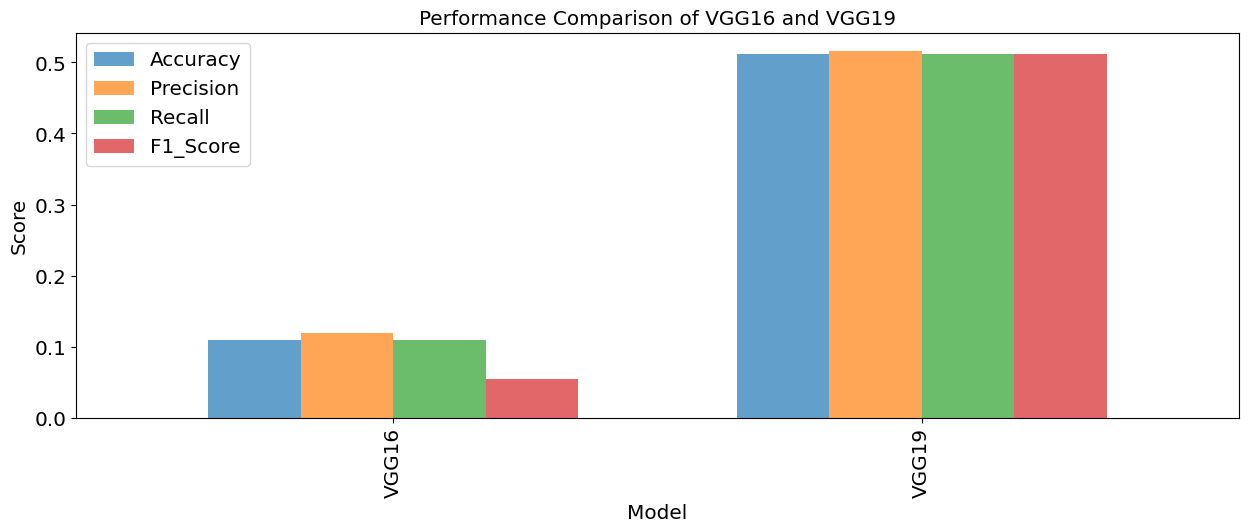

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

ErrorMetrics_pd = pd.DataFrame({
    'Accuracy': Accuracy,
    'Precision': Precision,
    'Recall': Recall,
    'F1_Score': F1_Score
}, index=['VGG16', 'VGG19'])

ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)

plt.title("Performance Comparison of VGG16 and VGG19")
plt.ylabel("Score")
plt.xlabel("Model")
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot graphs for Accuracy and Loss Function for VGG16 and VGG19 (4 graphs in total).
### 2. Based on this analysis, determine the optimal number of epochs for training your VGG16 and VGG19 models.
### 3. Copy your early-stop code

### 4. Add the final Performance Table

### 5. Plot the performance comparing histogram of VGG16 and VGG19

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# Access training history
val_loss = history.history['val_loss']

# Find epoch with lowest validation loss
optimal_epoch = np.argmin(val_loss) + 1

print("Optimal number of epochs:", optimal_epoch)

Optimal number of epochs: 39


<html> <h2 style="font-style:bold; color:red;"> Optional.
Extra mark. </h2> </html>

1. Use the base_model 'Inception-V3' pre-trained neural network model.
2. Add Inception-V3 results to the Performance table and Performance comparing histogram.

Epoch 1/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.2749 - loss: 2.0306 - val_accuracy: 0.4240 - val_loss: 1.6486
Epoch 2/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3888 - loss: 1.7218 - val_accuracy: 0.4527 - val_loss: 1.5732
Epoch 3/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4154 - loss: 1.6573 - val_accuracy: 0.4664 - val_loss: 1.5332
Epoch 4/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4344 - loss: 1.6111 - val_accuracy: 0.4801 - val_loss: 1.5047
Epoch 5/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4413 - loss: 1.5887 - val_accuracy: 0.4827 - val_loss: 1.4849
Epoch 6/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4479 - loss: 1.5687 - val_accuracy: 0.4899 - val_loss: 1.4654
Epoch 7/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4600 - loss: 1.5451 - val_accuracy: 0.4980 - val_loss: 1.4498
Epoch 8/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4600 - loss: 1.5308 

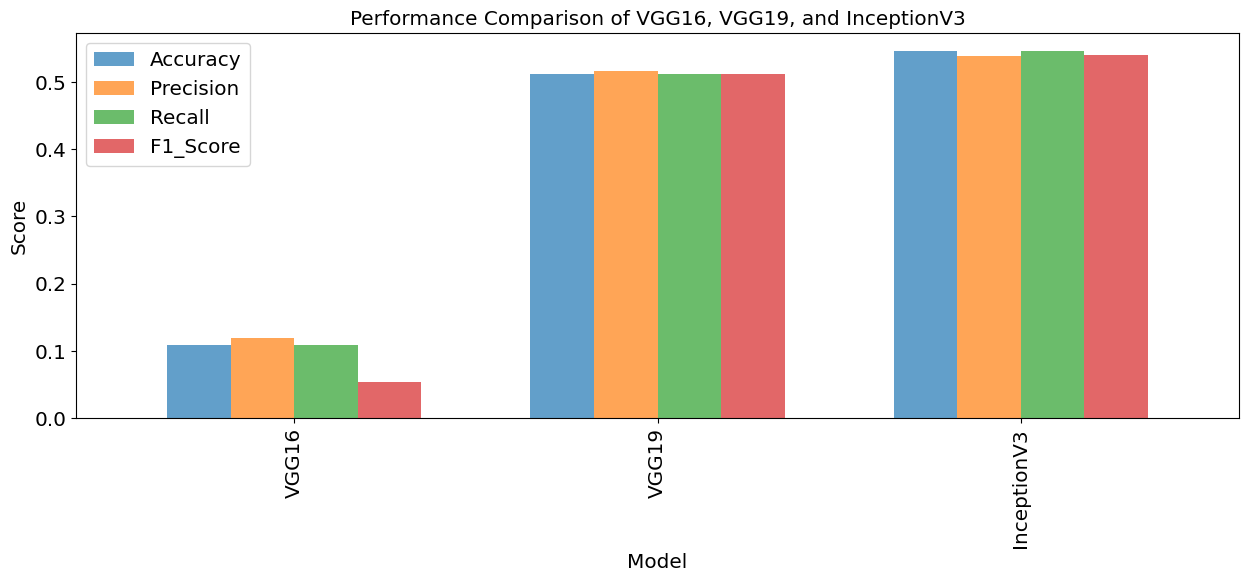

In [123]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers

# Resize images for InceptionV3
X_train_75 = tf.image.resize(X_train, (75,75))
X_val_75 = tf.image.resize(X_val, (75,75))
X_test_75 = tf.image.resize(X_test, (75,75))

# Create generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator_75 = train_datagen.flow(
    X_train_75,
    Y_train,
    batch_size=BATCH_SIZE
)

val_generator_75 = val_datagen.flow(
    X_val_75,
    Y_val,
    batch_size=BATCH_SIZE
)

# Load pre-trained InceptionV3
base_model_3 = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(75,75,3)
)

# Freeze base model
for layer in base_model_3.layers:
    layer.trainable = False

# Add classification layers
x = base_model_3.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)

model_3 = Model(inputs=base_model_3.input, outputs=pred)

# Compile model
model_3.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

# Train model
history_3 = model_3.fit(
    train_generator_75,
    validation_data=val_generator_75,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

# Predict
predictions_3 = model_3.predict(X_test_75/255.)
predictions_3 = np.argmax(predictions_3, axis=1)

# True labels
y_true = np.argmax(Y_test, axis=1)

# Calculate metrics
Accuracy.append(accuracy_score(y_true, predictions_3))
Precision.append(precision_score(y_true, predictions_3, average='macro'))
Recall.append(recall_score(y_true, predictions_3, average='macro'))
F1_Score.append(f1_score(y_true, predictions_3, average='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_Score)

# Create performance table
ErrorMetrics_pd = pd.DataFrame({
    'Accuracy': Accuracy,
    'Precision': Precision,
    'Recall': Recall,
    'F1_Score': F1_Score
}, index=['VGG16','VGG19','InceptionV3'])

print(ErrorMetrics_pd)

# Plot comparison histogram
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.title("Performance Comparison of VGG16, VGG19, and InceptionV3")
plt.ylabel("Score")
plt.xlabel("Model")
plt.show()